# 04 — Parameter Sweep
Grid search + Optuna over deltas, exits, and signal thresholds.
**Warning:** everything here is in-sample — notebook 05 is where claims get
tested out-of-sample.

### Parameter grid
Delta target (10/16/30Δ), take_profit (25/50/100%), stop_loss (-2x/none). Parallel sweep.


In [1]:
import sys
sys.path.insert(0, "../src")
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.width", 160)

### Sharpe heatmap
Light = bad, dark = good. Look for smooth peak (real edge), not jagged (noise).


In [2]:
from lab.backtest import StrategyConfig
from lab.experiments import grid_sweep, optuna_search
from lab.report import param_heatmap

base = StrategyConfig.from_yaml("../configs/short_put_45dte.yaml").replace(
    start="2016-01-01", end="2023-12-31")

### Max DD stability
Smooth degradation = stable edge. Cliffs = fragile.


In [3]:
grid = {
    "leg1_delta.target": [0.10, 0.16, 0.30],
    "take_profit":       [0.25, 0.5, None],
    "stop_loss":         [-2.0, None],
}
sweep = grid_sweep(base, grid, tag="sweep04")
sweep.head(10).round(3)

f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning:

,leg1_delta.target,take_profit,stop_loss,config_hash,error,n_trades,total_trades,winning_trades,losing_trades,win_rate,...,profit_factor,max_drawdown,avg_days_in_trade,sharpe_ratio,sortino_ratio,var_95,cvar_95,calmar_ratio,omega_ratio,tail_ratio
0,0.16,0.25,NaN,22f724f11536,NaN,451.0,451.0,432.0,19.0,0.958,...,3.372,-0.096,6.466,2.044,2.368,0.251,-1.978,0.985,3.570,0.0
1,0.16,0.50,NaN,fcc86c0f6599,NaN,277.0,277.0,258.0,19.0,0.931,...,3.319,-0.102,10.527,1.768,2.168,-0.735,-3.389,0.897,3.304,0.0
2,0.30,0.25,NaN,5904cf84fcab,NaN,384.0,384.0,359.0,25.0,0.935,...,2.720,-0.167,7.594,1.601,1.869,-0.416,-2.210,0.697,2.850,0.0
3,0.30,0.50,NaN,3d425daf2216,NaN,246.0,246.0,219.0,27.0,0.890,...,2.298,-0.186,11.854,1.205,1.442,-1.418,-3.326,0.580,2.341,0.0
4,0.16,NaN,NaN,9c7947e04510,NaN,314.0,314.0,232.0,82.0,0.739,...,1.576,-0.269,9.287,0.692,0.810,-1.241,-2.769,0.203,1.626,0.0
5,0.16,0.25,-2.0,0cb775eecd7d,NaN,524.0,524.0,483.0,41.0,0.922,...,1.442,-0.330,5.565,0.670,0.733,-2.461,-3.417,0.185,1.463,0.0
6,0.30,NaN,NaN,43435539347c,NaN,291.0,291.0,210.0,81.0,0.722,...,1.472,-0.355,10.021,0.632,0.772,-1.516,-2.812,0.207,1.523,0.0
7,0.16,0.50,-2.0,44d50a6d6471,NaN,317.0,317.0,281.0,36.0,0.886,...,1.467,-0.342,9.199,0.619,0.701,-2.934,-3.928,0.171,1.485,0.0
8,0.30,0.50,-2.0,3462a1050fab,NaN,275.0,275.0,237.0,38.0,0.862,...,1.403,-0.403,10.604,0.593,0.692,-2.688,-3.274,0.187,1.449,0.0
9,0.30,0.25,-2.0,646f195362f2,NaN,456.0,456.0,412.0,44.0,0.904,...,1.313,-0.473,6.395,0.517,0.571,-2.463,-3.065,0.151,1.348,0.0


### Optuna Bayesian search
TPE sampler + vix_rank threshold. Intelligent search >> exhaustive grid.


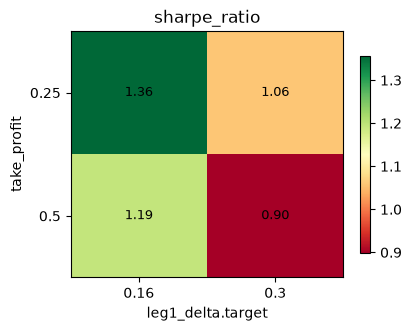

In [4]:
param_heatmap(sweep, x="leg1_delta.target", y="take_profit", metric="sharpe_ratio");

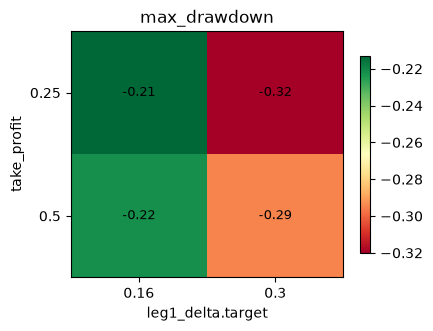

In [5]:
# Parameter stability: a real edge degrades smoothly around the optimum.
param_heatmap(sweep, x="leg1_delta.target", y="take_profit", metric="max_drawdown");

## Optuna for the bigger space (adds signal threshold)

In [6]:
def space(trial):
    return {
        "leg1_delta.target": trial.suggest_float("delta", 0.08, 0.35),
        "take_profit":       trial.suggest_float("take_profit", 0.2, 0.8),
        "entry_filter":      f"vix_rank > {trial.suggest_float('vix_rank_min', 0.0, 0.8):.2f}",
    }

study = optuna_search(base, space, n_trials=40, tag="optuna04")
print("best:", study.best_params, "->", round(study.best_value, 3))
study.trials_dataframe()[["number", "value", "params_delta", "params_take_profit", "params_vix_rank_min"]].tail(10)

f:\workspace\sophie-option-research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: invalid value encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: invalid value encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\em

best: {'delta': 0.1449532346685296, 'take_profit': 0.7388650804862225, 'vix_rank_min': 0.07140486905991114} -> 0.81


f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))


,number,value,params_delta,params_take_profit,params_vix_rank_min
30,30,-inf,0.080363,0.752806,0.069089
31,31,0.585289,0.176823,0.722377,0.109538
32,32,0.464289,0.142805,0.703056,0.253234
33,33,0.735615,0.110791,0.799698,0.180811
34,34,0.689722,0.112393,0.761670,0.048400
35,35,-inf,0.097809,0.779371,0.136369
36,36,0.672425,0.128387,0.695468,0.122701
37,37,0.441147,0.147936,0.796708,0.348731
38,38,0.649976,0.102584,0.747597,0.178393
39,39,0.796692,0.124780,0.799505,0.048602
